STARTING GRID SEARCH
Total combinations: 216
Parameters: ['vocab_size', 'classifier_type', 'knn_neighbors', 'svm_kernel', 'svm_C', 'use_feature_scaling']

PREPROCESSING DATA (ONE TIME ONLY)

Loading images from: UCMerced_LandUse
Found classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Loaded 2100 images from 21 classes
Descriptor method: CNN


/home/ayoub/miniconda3/envs/develop/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ayoub/miniconda3/envs/develop/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/ayoub/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [02:44<00:00, 3.37MB/s] 


  Processed 800/2100 images -> feature map 14x14, channels=512
  Processed 1600/2100 images -> feature map 14x14, channels=512
  Processed 2100/2100 images -> feature map 14x14, channels=512
Total CNN local descriptors (stacked): (411600, 512)

RUNNING EXPERIMENTS


[1/216] exp_001_vocab_size=50_classifier_type=knn_knn_neighbors=3_svm_kernel=linear_svm_C=0.1_use_feature_scaling=True

Running Experiment: exp_001_vocab_size=50_classifier_type=knn_knn_neighbors=3_svm_kernel=linear_svm_C=0.1_use_feature_scaling=True

>>> Using preprocessed data (skipping image loading and feature extraction)

>>> STEP 2: Building vocabulary (vocab_size=50)
Building vocabulary with 50 visual words...
Vocabulary built. Shape: (50, 512)

>>> STEP 3: Computing BoVW histograms
Computing BoVW histograms for 2100 images...
  Processed 500/2100 histograms
  Processed 1000/2100 histograms
  Processed 1500/2100 histograms
  Processed 2000/2100 histograms
Histograms computed. Shape: (2100, 50)

>>> Verifying data con

/home/ayoub/repos/school/3cs/cv/lab3.2/visualization.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


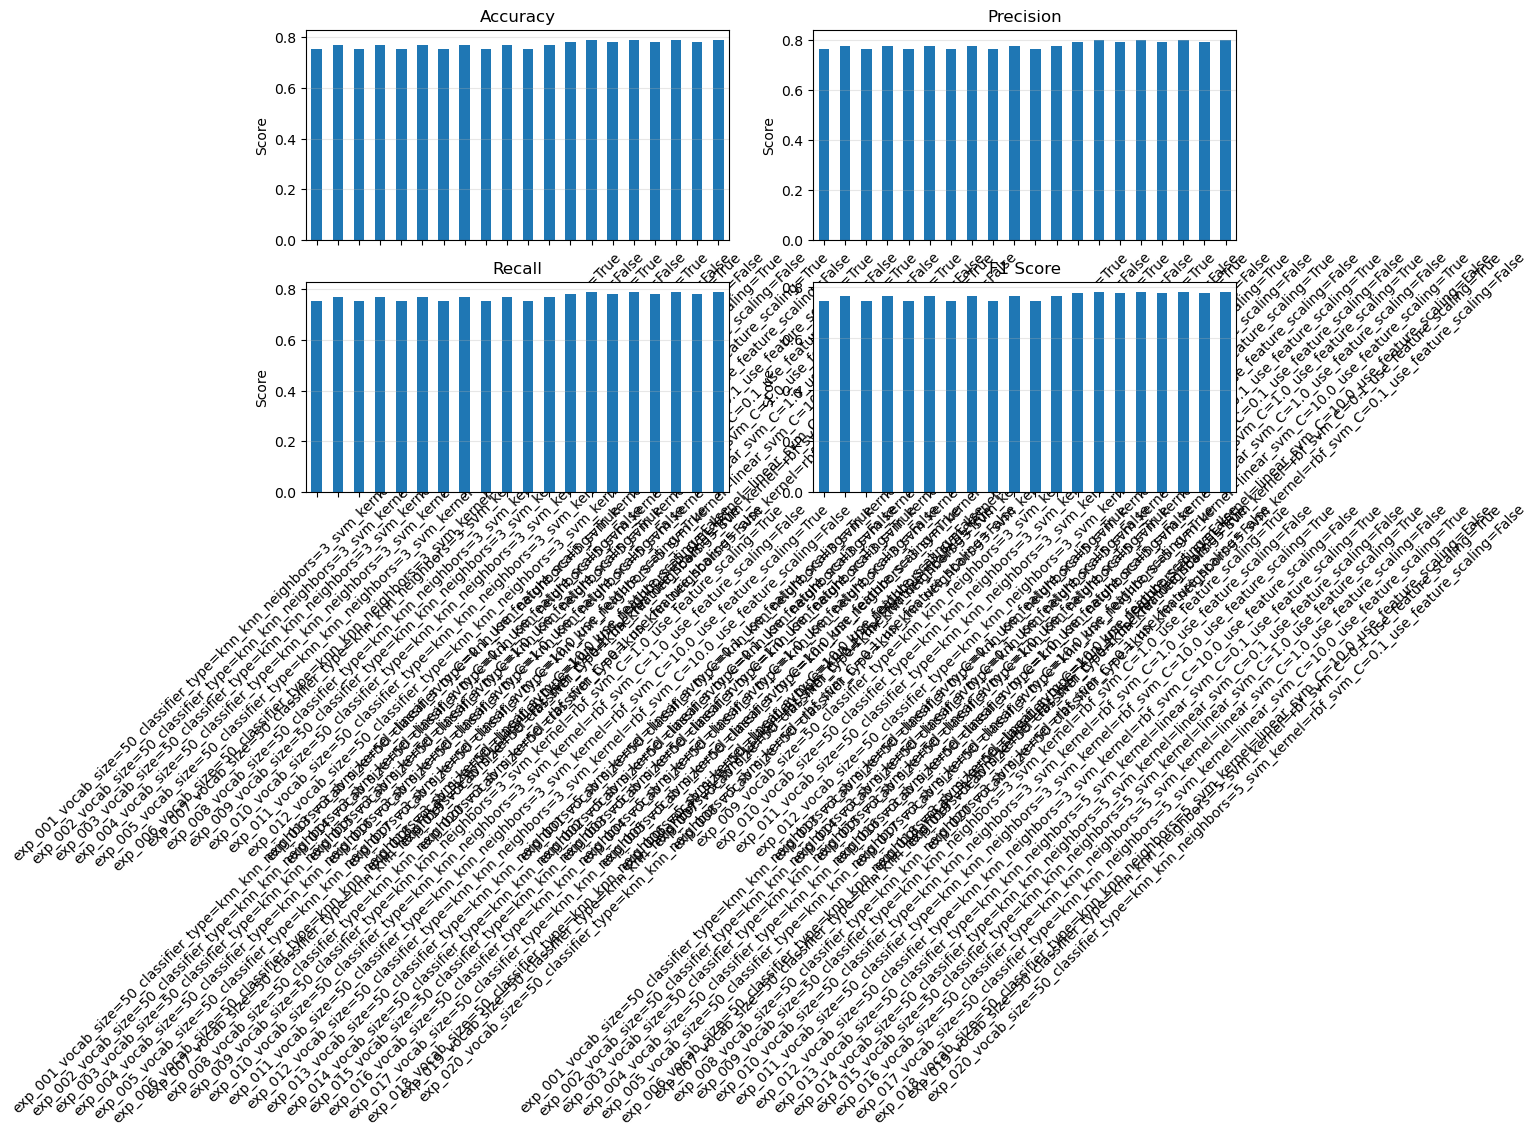

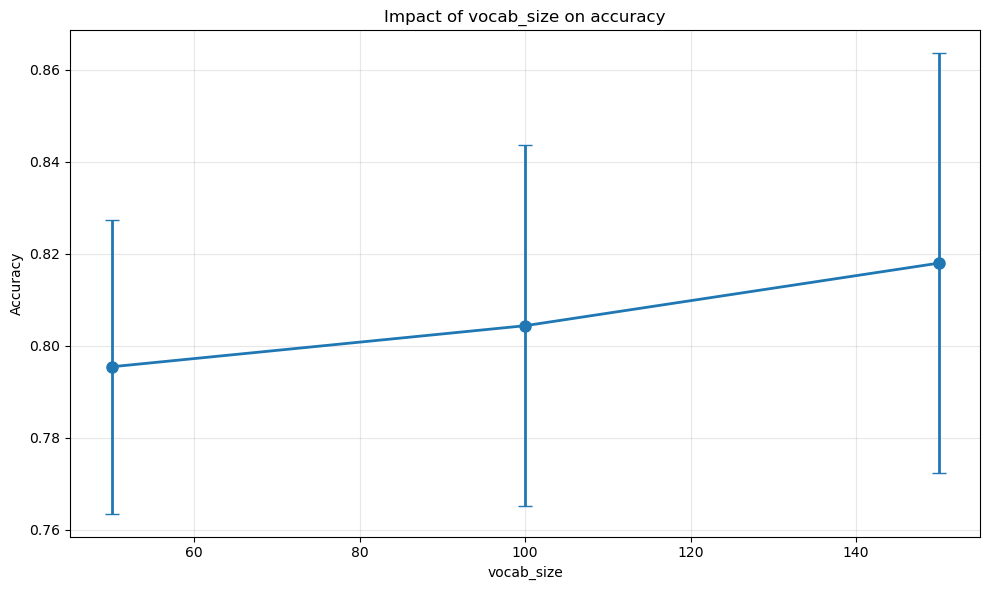

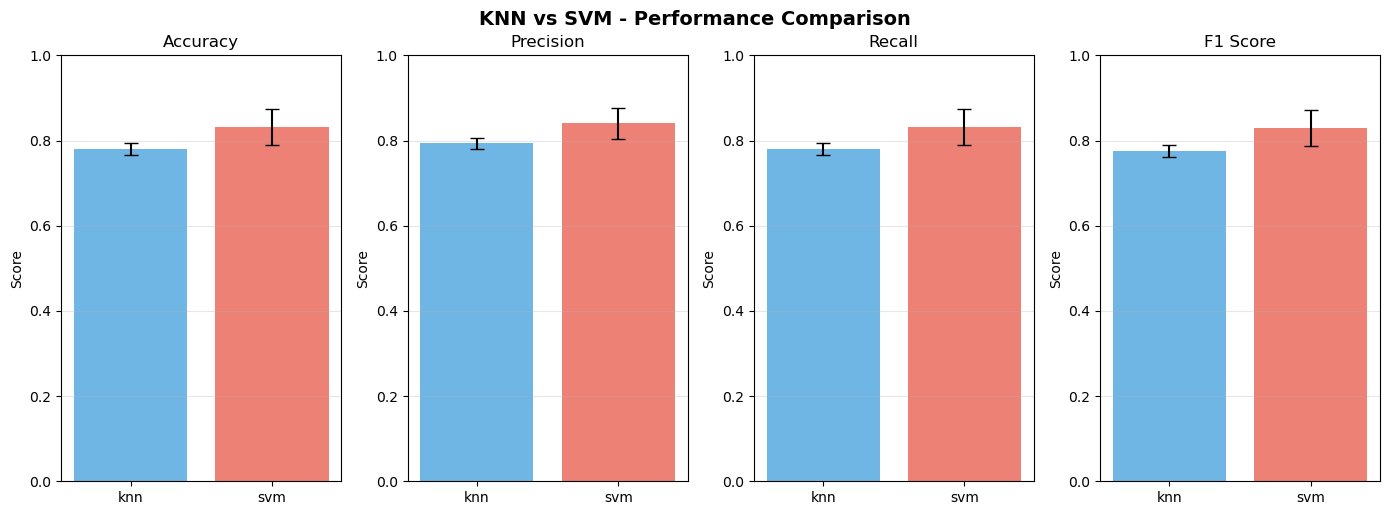

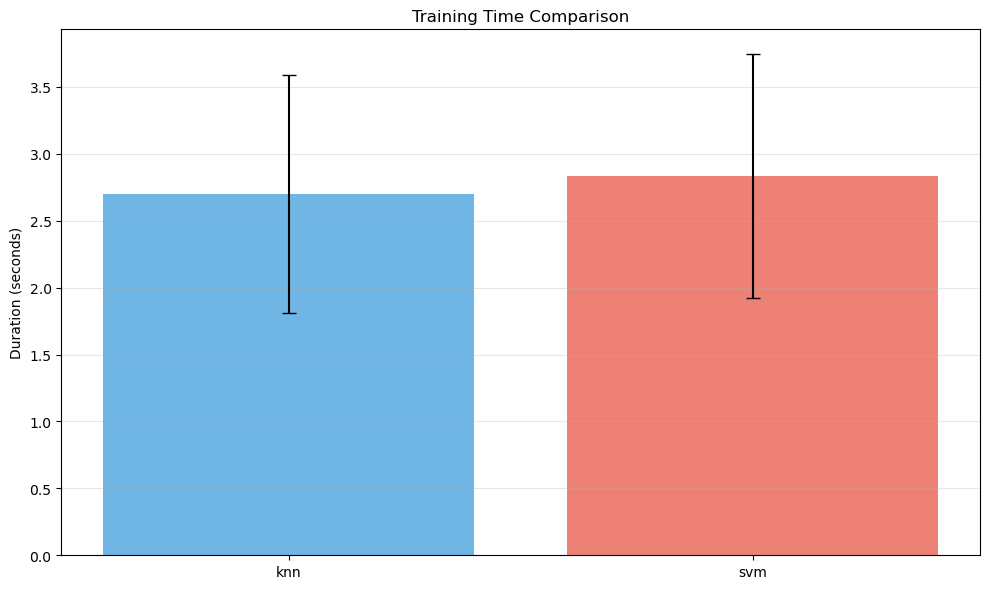


BEST KNN CONFIGURATION
Accuracy: 0.7976
Vocab Size: 50
K Neighbors: 7
Metric: euclidean

BEST SVM CONFIGURATION
Accuracy: 0.8905
Vocab Size: 150
Kernel: rbf
C: 1.0
Results DataFrame saved to: experiments/all_results.csv
Preprocessed data saved to: experiments/preprocessed_data.pkl

BEST OVERALL CONFIGURATION
experiment_name         exp_190_vocab_size=150_classifier_type=svm_knn...
timestamp                                      2025-11-23T14:48:41.914831
duration_seconds                                                 4.063854
classifier_type                                                       svm
vocab_size                                                            150
image_max_size                                                        400
normalize_histograms                                                 True
use_feature_scaling                                                 False
use_minibatch_kmeans                                                 True
knn_neighbors          

In [1]:
"""
Bag of Visual Words (BoVW) - Image Classification Experiment Framework
Main entry point for running experiments and hyperparameter tuning.
"""
from config import ExperimentConfig
from experiment import HyperparameterTuner
from visualization import ResultsVisualizer
from manager import ExperimentManager
from features import FeatureExtractor


    # Define base configuration
base_config = ExperimentConfig(
        data_dir="UCMerced_LandUse",
        experiment_description="Comprehensive grid search: KNN vs SVM",
        dsc_method="cnn"
    )
    
param_grid = {
        'vocab_size': [50, 100, 150],
        'classifier_type': ['knn', 'svm'],
        'knn_neighbors': [3, 5, 7],  
        'svm_kernel': ['linear', 'rbf'],  
        'svm_C': [0.1, 1.0, 10.0],  
        'use_feature_scaling': [True, False]
    }
    
    # Run grid search
tuner = HyperparameterTuner(base_config)
results_df = tuner.tune(param_grid)
    
    # Display results
print("\n" + "="*60)
print("GRID SEARCH RESULTS - TOP 10 CONFIGURATIONS")
print("="*60)
top_results = results_df.sort_values('accuracy', ascending=False).head(10)
print(top_results[['experiment_name', 'classifier_type', 'vocab_size', 
                       'accuracy', 'f1_score', 'duration_seconds']])
    
    # Compare KNN vs SVM
print("\n" + "="*60)
print("KNN vs SVM COMPARISON")
print("="*60)
comparison = results_df.groupby('classifier_type').agg({
        'accuracy': ['mean', 'std', 'max'],
        'f1_score': ['mean', 'std', 'max'],
        'duration_seconds': ['mean', 'std']
    }).round(4)
print(comparison)
    
visualizer = ResultsVisualizer()
visualizer.plot_metrics_comparison(results_df.head(20))
visualizer.plot_parameter_impact(results_df, 'vocab_size')
visualizer.plot_classifier_comparison(results_df)
visualizer.plot_training_time_comparison(results_df)

best_knn = results_df[results_df['classifier_type'] == 'knn'].sort_values('accuracy', ascending=False).iloc[0]
best_svm = results_df[results_df['classifier_type'] == 'svm'].sort_values('accuracy', ascending=False).iloc[0]

print("\n" + "="*60)
print("BEST KNN CONFIGURATION")
print("="*60)
print(f"Accuracy: {best_knn['accuracy']:.4f}")
print(f"Vocab Size: {best_knn['vocab_size']}")
print(f"K Neighbors: {best_knn['knn_neighbors']}")
print(f"Metric: {best_knn['knn_metric']}")

print("\n" + "="*60)
print("BEST SVM CONFIGURATION")
print("="*60)
print(f"Accuracy: {best_svm['accuracy']:.4f}")
print(f"Vocab Size: {best_svm['vocab_size']}")
print(f"Kernel: {best_svm['svm_kernel']}")
print(f"C: {best_svm['svm_C']}")

# Save results
manager = ExperimentManager()
manager.save_results_dataframe(results_df)
manager.save_preprocessed_data(tuner.preprocessed_data)



# Get best overall configuration
best_idx = results_df['accuracy'].idxmax()
best_config = results_df.loc[best_idx]
print("\n" + "="*60)
print("BEST OVERALL CONFIGURATION")
print("="*60)
print(best_config)
